## Section 0 — Environment Setup

Set up the environment following `00_setup.ipynb`

Also define the NEOK Bio brand color palette used consistently across all visualizations in this project

Set up the base URLs for the two public APIs we will be querying in this notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import os
import warnings
warnings.filterwarnings('ignore')

# NEOK Bio brand color palette — will be used consistently across all figures
NEOK_DARK =  '#0D4A47'  # darkest teal 
NEOK_MID =   '#0D7A6E'  # mid teal
NEOK_TEAL =  '#0D9488'  # standard teal 
NEOK_LIGHT = '#BBF7D0'  # lightest 

# create output directories
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/images', exist_ok=True)

# The public API base URLs (no authentication required for either)

#Proteomic Data Commons (PDC) — CPTAC protein mass spectrometry
#GraphQL API, no authentication required
PDC_BASE = "https://pdc.cancer.gov/graphql"
#ClinicalTrials.gov v2 REST API — no authentication required
CT_BASE  = "https://clinicaltrials.gov/api/v2"

#Double check packages are installed and versions are compatible
print(f"pandas     {pd.__version__}")
print(f"numpy      {np.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")
print("Setup complete")

pandas     3.0.2
numpy      2.4.3
matplotlib 3.10.8
Setup complete


---

## Section 1 — ABL Bio TMA IHC Expression Data (Method 1 Approach)

### Expression Scoring - Weighted Score:
For this Method 1 scoring, a **weighted combination** of both positivity metrics is used:
`TMA weighted score = (% any positive × 0.4) + (% H-score >100 × 0.6)`

**Reasoning:**
- `% any positive (H>0)`: even low H-score expression can support bispecific ADC binding; presence matters for a dual-targeting strategy
- `% targetable (H>100)`: higher intensity means more ADC binding sites per cell; more clinically relevant for efficacy so weighted higher (0.6)
- The weighted approach prevents low-intensity indications from scoring the same as truly negative indications, while also rewarding high-intensity expression
- Avoids the problem where using H>100 alone would score almost all indications the same (near zero) for ROR1, losing all discriminating power

In [2]:
#TMA IHC data entry - From ABL Bio TMA IHC slide (visually measured using plotdigitizer, rounded to whole number)
    #Format: [pct_H0, pct_H1to100, pct_H101to200, pct_H201to300] 
        #pct_H0 = % tumors with H-score 0 (no staining)
        #pct_H1to100 = % tumors with H-score 1-100 (low staining)
        #pct_H101to200 = % tumors with H-score 101-200 (moderate staining)
        #pct_H201to300 = % tumors with H-score 201-300 (high staining)
    #Each row sums to ~100%

# Indications on the TMA slide:
#   Lung, Head & Neck, TNBC, Breast (non-TNBC), Ovarian, Neuroendocrine, Gastric, SCLC, Sarcoma, Prostate

# Indications NOT on the TMA slide:
#   Pancreatic, Colorectal, Cervical, Endometrial, NSCLC adeno/squamous not separated (both use Lung bar)

tma_raw = {
    # Lung bar — applied to both NSCLC adeno and squamous as no subtype separation in presentation slide
    'NSCLC (Lung Adeno)': {
        'ROR1': [21, 71, 8, 0],
        'B7H3': [12, 78, 8, 2], #see tiny sliver of purple so estimate ~2%
    },
    'NSCLC (Lung Squamous)': {
        'ROR1': [21, 71, 8, 0], # same as adeno — limitation noted
        'B7H3': [12, 78, 8, 2],
    },
    'HNSCC': {
        'ROR1': [25, 70, 5, 0],
        'B7H3': [6, 74, 17, 3],   # highest B7H3 total positive on slide
    },
    'TNBC (Breast)': {
        'ROR1': [30, 69, 1, 0], #See a tiny sliver of blue; estimating 1%
        'B7H3': [9, 58, 28, 5],
    },
    'Ovarian': {
        'ROR1': [40, 60, 0, 0],
        'B7H3': [15, 81, 4, 0],
    },
    'Neuroendocrine': {
        'ROR1': [54, 44, 2, 0],   # moderate ROR1 ~46% total positive
        'B7H3': [30, 63, 6, 1],   #See a tiny sliver purple, estimating 1%
    },
    'Gastric/GEJ': {
        'ROR1': [62, 38, 0, 0],
        'B7H3': [51, 47, 1, 1], #See a tiny sliver purple and blue
    },
    'SCLC': {
        'ROR1': [64, 36, 0, 0],
        'B7H3': [13, 72, 12, 3],
    },
    # NOT on the TMA slide — no data
    'Colorectal':    None,
    'Pancreatic':    None,
    'Cervical':      None,
    'Endometrial':   None,
}

def pct_any_positive(dist):
    """
    % tumors with any detectable expression (H-score > 0).
    Sums all non-zero bins: H(1-100) + H(101-200) + H(201-300).
    """
    return dist[1] + dist[2] + dist[3]

def pct_targetable(dist):
    """
    % tumors with H-score > 100 (moderate + high expression).
    Clinically relevant threshold for ADC binding efficacy.
    """
    return dist[2] + dist[3]

def tma_weighted(dist):
    """
    Weighted expression score from TMA H-score distribution.

    Combines presence (any positive) and intensity (H>100):
        weighted = (% any positive × 0.4) + (% targetable × 0.6)

    Rationale:
        Even low H-score (1-100) expression matters for bispecific ADC binding - weighted at 0.4 to capture presence
        A H-score > 100 is more clinically relevant for ADC efficacy - weighted higher at 0.6
        This prevents near-zero ROR1 targetable from losing all discriminating power across indications
    """
    pos  = pct_any_positive(dist)
    targ = pct_targetable(dist)
    return round(pos * 0.4 + targ * 0.6, 1)

# build TMA summary dataframe
tma_rows = []
for indication, data in tma_raw.items():
    if data is None:
        tma_rows.append({
            'Indication':         indication,
            'on_tma_slide':       False,
            'ROR1_H0':            None, 'ROR1_H1_100':   None,
            'ROR1_H101_200':      None, 'ROR1_H201_300': None,
            'ROR1_pct_positive':  None, 'ROR1_pct_targetable': None,
            'ROR1_weighted':      None,
            'B7H3_H0':            None, 'B7H3_H1_100':   None,
            'B7H3_H101_200':      None, 'B7H3_H201_300': None,
            'B7H3_pct_positive':  None, 'B7H3_pct_targetable': None,
            'B7H3_weighted':      None,
        })
    else:
        tma_rows.append({
            'Indication':          indication,
            'on_tma_slide':        True,
            'ROR1_H0':             data['ROR1'][0],
            'ROR1_H1_100':         data['ROR1'][1],
            'ROR1_H101_200':       data['ROR1'][2],
            'ROR1_H201_300':       data['ROR1'][3],
            'ROR1_pct_positive':   pct_any_positive(data['ROR1']),
            'ROR1_pct_targetable': pct_targetable(data['ROR1']),
            'ROR1_weighted':       tma_weighted(data['ROR1']),
            'B7H3_H0':             data['B7H3'][0],
            'B7H3_H1_100':         data['B7H3'][1],
            'B7H3_H101_200':       data['B7H3'][2],
            'B7H3_H201_300':       data['B7H3'][3],
            'B7H3_pct_positive':   pct_any_positive(data['B7H3']),
            'B7H3_pct_targetable': pct_targetable(data['B7H3']),
            'B7H3_weighted':       tma_weighted(data['B7H3']),
        })

tma_df = pd.DataFrame(tma_rows)

# also store weighted scores dict for use in later scoring cells
tma_weighted_scores = {}
for indication, data in tma_raw.items():
    if data is None:
        tma_weighted_scores[indication] = {'ror1': None, 'b7h3': None}
    else:
        tma_weighted_scores[indication] = {
            'ror1': tma_weighted(data['ROR1']),
            'b7h3': tma_weighted(data['B7H3']),
        }

# print summary table
print("=== ABL BIO TMA IHC — EXPRESSION SUMMARY ===\n")
print(f"{'Indication':<25} {'ROR1 any+':>9} {'ROR1 H>100':>10} "
      f"{'ROR1 wtd':>9} {'B7H3 any+':>9} {'B7H3 H>100':>10} "
      f"{'B7H3 wtd':>9}  {'Slide':>5}")
print("-" * 100)

for _, row in tma_df.iterrows():
    def fmt(val, pct=True):
        if pd.isna(val):
            return "N/A"
        return f"{int(val)}%" if pct else f"{val:.1f}"

    print(f"{row['Indication']:<25} "
          f"{fmt(row['ROR1_pct_positive']):>9} "
          f"{fmt(row['ROR1_pct_targetable']):>10} "
          f"{fmt(row['ROR1_weighted'], pct=False):>9} "
          f"{fmt(row['B7H3_pct_positive']):>9} "
          f"{fmt(row['B7H3_pct_targetable']):>10} "
          f"{fmt(row['B7H3_weighted'], pct=False):>9}  "
          f"{'Yes' if row['on_tma_slide'] else 'No':>5}")

print("""
Weighted score = (% any positive × 0.4) + (% H-score >100 × 0.6)

""")

tma_df.to_csv('../data/processed/abl_bio_tma_ihc.csv', index=False)
print("Saved to data/processed/abl_bio_tma_ihc.csv")

=== ABL BIO TMA IHC — EXPRESSION SUMMARY ===

Indication                ROR1 any+ ROR1 H>100  ROR1 wtd B7H3 any+ B7H3 H>100  B7H3 wtd  Slide
----------------------------------------------------------------------------------------------------
NSCLC (Lung Adeno)              79%         8%      36.4       88%        10%      41.2    Yes
NSCLC (Lung Squamous)           79%         8%      36.4       88%        10%      41.2    Yes
HNSCC                           75%         5%      33.0       94%        20%      49.6    Yes
TNBC (Breast)                   70%         1%      28.6       91%        33%      56.2    Yes
Ovarian                         60%         0%      24.0       85%         4%      36.4    Yes
Neuroendocrine                  46%         2%      19.6       70%         7%      32.2    Yes
Gastric/GEJ                     38%         0%      15.2       49%         2%      20.8    Yes
SCLC                            36%         0%      14.4       87%        15%      43.8    Ye

---

## Section 2 — CPTAC Protein Expression Data (Method 2 Approach)

### About the PDC API
Data is accessed via the **PDC (Proteomic Data Commons)** GraphQL API at pdc.cancer.gov. This is fully public, with no authentication required.

### Of note:
`quantDataMatrix` returns data in two different matrix formats depending on the study:

**Format A** (most studies):
```
Row 0:  ['Gene/Aliquot', 'aliquot_id_1', 'aliquot_id_2', ...]
Row 1+: ['GENE_NAME',    log2_val_1,     log2_val_2,     ...]
```

**Format B** (e.g. CPTAC STAD gastric study):
```
Row 0:  ['Gene/Aliquot', 'gene_name:-666', 'aliquot_id_1', ...]
Row 1+: ['uuid',         'GENE_NAME',      log2_val_1,     ...]
```

<br>

_So if header row col 1 contains `'gene_name'`, this is Format B. The fetch function below will handle both format automatically._


### **2.1 — Verify API and explore all available CPTAC studies:**

First, I get the full list of all CPTAC proteome studies with disease types; so we can see exactly what cancer types are available

In [3]:
# verify PDC API is reachable
r = requests.post(
    PDC_BASE,
    json={"query": "{ uiStudySummary { study_name disease_type analytical_fraction } }"},
    headers={"Content-Type": "application/json"},
    timeout=15
)
assert r.status_code == 200, "PDC API not reachable"

all_studies = r.json()['data']['uiStudySummary']
print(f"PDC API reachable — {len(all_studies)} total studies available")

# filter to proteome fraction only
# other fractions (phosphoproteome, acetylome etc) not relevant for ADC targeting
proteome_studies = [
    s for s in all_studies
    if s['analytical_fraction'] == 'Proteome'
]
print(f"Proteome studies: {len(proteome_studies)}")

# show all proteome studies — skip reference/normal/PDX studies; which are not tumor patient cohorts
print(f"\n{'Study Name':<55} {'Disease Type'}")
print("-" * 110)

SKIP_KEYWORDS = [
    'CompRef', 'Normal', 'PDX', 'Cell Line', 'Xenograft',
    'Reproducible', 'NCI-7', 'Cyst', 'IPMN'
]

for s in sorted(proteome_studies, key=lambda x: x['study_name']):
    if any(k in s['study_name'] for k in SKIP_KEYWORDS):
        continue
    print(f"{s['study_name']:<55} {s['disease_type'][:55]}")

PDC API reachable — 227 total studies available
Proteome studies: 99

Study Name                                              Disease Type
--------------------------------------------------------------------------------------------------------------
AML Ex Vivo Drug Response - Combination Treatment - Proteome Acute Myeloid Leukemia;Other
AML Ex Vivo Drug Response - Primary Cohort - Proteome   Acute Myeloid Leukemia;Other
AML Ex Vivo Drug Response - Sorafenib Treatment - Proteome Acute Myeloid Leukemia;Other
AML Gilteritinib Resistance -  Proteome                 Acute Myeloid Leukemia;Other
AML Gilteritinib TimeCourse -  Proteome                 Acute Myeloid Leukemia;Other
AML Quizartinib Resistance -  Proteome                  Acute Myeloid Leukemia;Other
APOLLO LUAD - Proteome                                  Lung Adenocarcinoma;Other
APOLLO-OV - Proteome                                    Epithelial Neoplasms, NOS;Other
Academia Sinica Gastric Cancer - Proteome               Other;

### **2.2 - Study Selection**

From the resulting 96 proteome studies available in PDC, I identified candidate studies for each of the 12 indications and examined the further for ROR1 and B7-H3 metrics (seen in code below).

**Selection criteria (in order):**
To select which study to use, these criteria were examined:
1. Disease type matches indication specifically
2. Largest sample size (more patients = more reliable metrics)
3. Data availability confirmed (tested `quantDataMatrix` API response before finalizing selection)

#### Studies with multiple CPTAC candidates tested:

| Indication | Studies Tested | Selected | Reason |
|-----------|---------------|----------|--------|
| NSCLC Adeno | Discovery, Confirmatory, APOLLO | **Confirmatory** | Largest n=270, 100% both genes detected |
| Gastric/GEJ | CPTAC STAD, Proteogenomics GC | **CPTAC STAD** | Proteogenomics GC is on early-onset gastric (different biology) |
| Pancreatic | CPTAC PDA, KU PDAC | **CPTAC PDA** | Larger n=212/230, broader patient cohort |
| Ovarian | PTRC HGSOC FFPE, PTRC Frozen | **PTRC HGSOC FFPE** | Largest n=190/210 |
| Endometrial | UCEC Confirmatory, UCEC Discovery | **UCEC Confirmatory** | UCEC Discovery returned null matrix |

#### Indications with no CPTAC data available:

| Indication | Studies Tested | Result |
|-----------|---------------|--------|
| SCLC | None in PDC | No SCLC proteomics study exists in PDC |
| Colorectal | TCGA Colon, Prospective Colon PNNL, Prospective Colon VU | All return null matrix |
| Cervical | KU CCA Discovery | Returns null matrix |
| Neuroendocrine | NF-PNET PhaseI, PhaseII, Validation | All return null matrix |

#### TNBC Note:
ROR1 was not detected in the TNBC proteomics study in PDC (8,844 proteins quantified, ROR1 absent)
- This is biologically meaningful; consistent with literature showing ROR1 protein is not expressed at detectable levels in breast cancer proteomics
- Though the sample size, n=30, is small
- On the other hand, B7H3 is detected and quantified (n=30, 100%)
- But because ROR1 was not detected, Method 2 will not be used for TNBC

In [4]:
#Protein fetch function for log2 abundance, handling both Format A and Format B matrix structures
def get_protein_abundance(study_name, gene_name):
    """
    Fetch protein log2 abundance for a gene from a CPTAC PDC study.

    Handles two matrix formats returned by quantDataMatrix:
      Format A: col 0 = gene name, cols 1+ = per-sample log2 values
      Format B: col 0 = UUID, col 1 = gene name, cols 2+ = log2 values
                detected by 'gene_name' string in header col 1

    Args:
        study_name = full PDC study submitter name string
        gene_name: = HUGO gene symbol ('ROR1' or 'CD276' for B7H3)

    Returns:
        dict with n_samples, median_log2, mean_log2, pct_detected
        or None if gene not found or study has no data
    """
    query = f"""
    {{
      quantDataMatrix(
        study_submitter_id: "{study_name}"
        data_type: "log2_ratio"
        acceptDUA: true
      )
    }}
    """
    r = requests.post(
        PDC_BASE,
        json={"query": query},
        headers={"Content-Type": "application/json"},
        timeout=30
    )

    if r.status_code != 200:
        return None
    data = r.json()
    if 'errors' in data:
        return None

    matrix = data['data']['quantDataMatrix']
    if not matrix or len(matrix) < 2:
        return None

    header = matrix[0]

    # detect Format B — header col 1 contains 'gene_name:-666'
    is_format_b = (
        len(header) > 1 and
        'gene_name' in str(header[1]).lower()
    )

    def extract_values(row, start_col):
        """Extract valid numeric log2 values, skip NaN strings."""
        values = []
        for v in row[start_col:]:
            try:
                val = float(v)
                if not np.isnan(val):
                    values.append(val)
            except (ValueError, TypeError):
                pass
        return values

    if is_format_b:
        # Format B: col 0 = UUID, col 1 = gene name, cols 2+ = values
        for row in matrix[1:]:
            if len(row) > 1 and row[1] == gene_name:
                values = extract_values(row, 2)
                if not values:
                    return None
                return {
                    'n_samples':    len(values),
                    'median_log2':  round(np.median(values), 3),
                    'mean_log2':    round(np.mean(values), 3),
                    'pct_detected': round(len(values)/(len(row)-2)*100, 1),
                }
    else:
        # Format A: col 0 = gene name, cols 1+ = values
        for row in matrix[1:]:
            if row[0] == gene_name:
                values = extract_values(row, 1)
                if not values:
                    return None
                return {
                    'n_samples':    len(values),
                    'median_log2':  round(np.median(values), 3),
                    'mean_log2':    round(np.mean(values), 3),
                    'pct_detected': round(len(values)/(len(row)-1)*100, 1),
                }
    return None

In [5]:
# test all candidate studies per indication to confirm data availability and select best study
# this is the full exploration ran to arrive at final selections

# test all relevant studies for ROR1 and CD276 data availability; to confirm which indications have CPTAC data for both targets
candidates = {
    'NSCLC (Lung Adeno)': [
        'CPTAC LUAD Discovery Study - Proteome',
        'CPTAC LUAD Confirmatory Study - Proteome',
        'APOLLO LUAD - Proteome',
    ],
    'NSCLC (Lung Squamous)': [
        'CPTAC LSCC Discovery Study - Proteome',
    ],
    'SCLC':          [],  # no study in PDC
    'Gastric/GEJ': [
        'CPTAC STAD Study - Proteome',
        'Proteogenomics of Gastric Cancer - Proteome',
    ],
    'Colorectal': [
        'TCGA Colon Cancer Proteome',
        'Prospective Colon PNNL Proteome Qeplus',
        'Prospective Colon VU Proteome',
    ],
    'Pancreatic': [
        'CPTAC PDA Discovery Study - Proteome',
        'KU PDAC Discovery Study - Global proteome',
    ],
    'Ovarian': [
        'PTRC HGSOC FFPE Discovery - Proteome',
        'PTRC HGSOC Frozen Validation - Proteome',
    ],
    'Cervical': [
        'KU CCA Discovery Study - Global proteome',
    ],
    'Endometrial': [
        'CPTAC UCEC Confirmatory Study - Proteome',
        'CPTAC UCEC Discovery Study - Proteome',
    ],
    'HNSCC': [
        'CPTAC HNSCC Discovery Study - Proteome',
    ],
    'TNBC (Breast)': [
        'PTRC TNBC - Proteome',
        'Yonsei Cancer Center - TNBC - Proteome',
    ],
    'Neuroendocrine': [
        'NF-PNET Discovery Study - Proteome - PhaseI',
        'NF-PNET Discovery Study - Proteome - PhaseII',
        'NF-PNET Validation Study - DIA',
    ],
}

print("Testing all candidate studies for ROR1 and CD276...")

all_results = {}

for indication, studies in candidates.items():
    print(f"\n=== {indication} ===")
    all_results[indication] = []

    if not studies:
        print("  No CPTAC study available in PDC")
        continue

    for study in studies:
        ror1 = get_protein_abundance(study, 'ROR1')
        b7h3 = get_protein_abundance(study, 'CD276')

        has_data = ror1 is not None and b7h3 is not None
        ror1_only = ror1 is not None and b7h3 is None
        b7h3_only = b7h3 is not None and ror1 is None

        if has_data:
            status = 'COMPLETE'
        elif ror1_only:
            status = 'ROR1 only'
        elif b7h3_only:
            status = 'B7H3 only'
        else:
            status = 'NO DATA'

        all_results[indication].append({
            'study': study, 'ror1': ror1,
            'b7h3': b7h3, 'status': status
        })

        ror1_str = (f"log2={ror1['median_log2']} "
                    f"n={ror1['n_samples']} "
                    f"({ror1['pct_detected']}% detected)"
                    if ror1 else "not found")
        b7h3_str = (f"log2={b7h3['median_log2']} "
                    f"n={b7h3['n_samples']} "
                    f"({b7h3['pct_detected']}% detected)"
                    if b7h3 else "not found")

        print(f"  [{status}] {study}")
        print(f"    ROR1:  {ror1_str}")
        print(f"    B7H3:  {b7h3_str}")

Testing all candidate studies for ROR1 and CD276...

=== NSCLC (Lung Adeno) ===
  [COMPLETE] CPTAC LUAD Discovery Study - Proteome
    ROR1:  log2=0.069 n=214 (96.0% detected)
    B7H3:  log2=-0.04 n=223 (100.0% detected)
  [COMPLETE] CPTAC LUAD Confirmatory Study - Proteome
    ROR1:  log2=0.002 n=270 (100.0% detected)
    B7H3:  log2=-0.006 n=270 (100.0% detected)
  [COMPLETE] APOLLO LUAD - Proteome
    ROR1:  log2=0.045 n=80 (80.0% detected)
    B7H3:  log2=0.024 n=100 (100.0% detected)

=== NSCLC (Lung Squamous) ===
  [COMPLETE] CPTAC LSCC Discovery Study - Proteome
    ROR1:  log2=0.2 n=190 (86.4% detected)
    B7H3:  log2=-0.136 n=220 (100.0% detected)

=== SCLC ===
  No CPTAC study available in PDC

=== Gastric/GEJ ===
  [COMPLETE] CPTAC STAD Study - Proteome
    ROR1:  log2=0.153 n=187 (84.6% detected)
    B7H3:  log2=-0.207 n=221 (100.0% detected)
  [COMPLETE] Proteogenomics of Gastric Cancer - Proteome
    ROR1:  log2=-0.105 n=110 (84.6% detected)
    B7H3:  log2=0.417 n=130 

In [7]:
# ── SCLC External Validation — Liu et al. Cell 2024, DOI: 10.1016/j.cell.2023.12.004, Table S3A─────────────────────────
#
# No CPTAC study available in PDC for SCLC.
# External validation via Liu et al.: which was proteogenomic characterization of 112 Chinese SCLC specimens (TMT-MS).
# Used their Table S3A: differential protein expression, tumor vs normal adjacent tissue.
#
# Gene symbols queried: ROR1, CD276 (HUGO symbol for B7-H3)

import pandas as pd

sclc_path = '../data/raw/SCLC_Proteogenomic_Liuetal.2024_TableS3.xlsx'
s3a = pd.read_excel(sclc_path, sheet_name='Table S3A')

results = {}
for gene in ['ROR1', 'CD276']:
    hit = s3a[s3a['Gene.symbol'] == gene]
    if len(hit) > 0:
        results[gene] = {
            'log2_fc':  hit['Log2.median.foldchange'].values[0],
            'pvalue':   hit['P.value'].values[0],
            'fdr':      hit['FDR'].values[0],
            'detected': True
        }
    else:
        results[gene] = {'detected': False}

# ── PRINT SUMMARY ────────────────────────────────────────────────────────────
print("=" * 65)
print("SCLC - External Proteomics Validation (Liu et al., Cell 2024)")
print("=" * 65)
print(f"{'Gene':<10} {'Detected':<10} {'Log2FC (T/NAT)':<18} "
      f"{'P-value':<12} {'FDR'}")
print("-" * 65)

for gene, res in results.items():
    if res['detected']:
        print(f"{gene:<10} {'Yes':<10} {res['log2_fc']:<18.4f} "
              f"{res['pvalue']:<12.4f} {res['fdr']:.4f}")
    else:
        print(f"{gene:<10} {'No':<10} {'—':<18} {'—':<12} {'—'}")

print()

SCLC - External Proteomics Validation (Liu et al., Cell 2024)
Gene       Detected   Log2FC (T/NAT)     P-value      FDR
-----------------------------------------------------------------
ROR1       No         —                  —            —
CD276      Yes        -0.0486            0.4905       0.5078



#### SCLC Note:
So like TNBC, ROR1 was not detected in this proteomics study 
- Because ROR1 was not detected, Method 2 will not be used for SCLC either

### **2.3 - Final Study Selection**

In [8]:
# final CPTAC study selection per indication rationale, documented in section's markdown above

CPTAC_FINAL = {
    # NSCLC Adeno: Confirmatory chosen — largest n=270, 100% both genes detected
    'NSCLC (Lung Adeno)':    'CPTAC LUAD Confirmatory Study - Proteome',
    # NSCLC Squamous: only one study available
    'NSCLC (Lung Squamous)': 'CPTAC LSCC Discovery Study - Proteome',
    # Gastric: CPTAC STAD chosen — CEO's TMA IHC slide confirms moderate B7H3 consistent with STAD result; Also proteogenomics study is early-onset gastric (a diff. biology)
    'Gastric/GEJ':           'CPTAC STAD Study - Proteome',
    # Pancreatic: CPTAC PDA larger sample size and is the primary CPTAC program study
    'Pancreatic':            'CPTAC PDA Discovery Study - Proteome',
    # Ovarian: FFPE Discovery largest sample size (n=190/210)
    'Ovarian':               'PTRC HGSOC FFPE Discovery - Proteome',
    # Endometrial: Confirmatory has data; Discovery returned a null matrix
    'Endometrial':           'CPTAC UCEC Confirmatory Study - Proteome',
    # HNSCC: only one study available; though note of low ROR1 detection (29.6%, n=59), which is inconsistent with ABL Bio's TMA IHC slide showing strong ROR1 detection
    'HNSCC':                 'CPTAC HNSCC Discovery Study - Proteome',
    # TNBC: B7H3 only — ROR1 detection absent from all samples (n=30)
    'TNBC (Breast)':         'PTRC TNBC - Proteome',
    # No CPTAC study available:
    'SCLC':          None,  # no SCLC proteomics
    'Colorectal':    None,  # all colon studies return null matrix
    'Cervical':      None,  # KU CCA returns null matrix
    'Neuroendocrine': None, # NF-PNET returns null for all data types
}

print("Pulling final CPTAC protein abundance per indication...")

cptac_data = {}

for indication, study in CPTAC_FINAL.items():
    if study is None:
        print(f"  {indication}: no CPTAC data available")
        cptac_data[indication] = {
            'ror1': None, 'b7h3': None, 'study': None}
        continue

    print(f"  {indication}...", end=" ")
    ror1 = get_protein_abundance(study, 'ROR1')
    b7h3 = get_protein_abundance(study, 'CD276')

    cptac_data[indication] = {
        'ror1': ror1, 'b7h3': b7h3, 'study': study}

    ror1_str = (f"log2={ror1['median_log2']} "
                f"n={ror1['n_samples']} "
                f"({ror1['pct_detected']}% detected)"
                if ror1 else "NOT FOUND")
    b7h3_str = (f"log2={b7h3['median_log2']} "
                f"n={b7h3['n_samples']} "
                f"({b7h3['pct_detected']}% detected)"
                if b7h3 else "NOT FOUND")
    print(f"ROR1: {ror1_str} | B7H3: {b7h3_str}")

# ── SCLC: input external validation values (Liu et al. Cell 2024) ───────────
# ROR1: absent from SCLC proteome — keep None
# CD276: log2FC = -0.0486 vs NAT, n=112, p=0.490 (from Table S3A)
# Note: log2FC (tumor vs NAT) not directly comparable to CPTAC log2 ratio used for visualization only — flagged in study column
cptac_data['SCLC']['b7h3'] = {
    'median_log2':  -0.0486,
    'n_samples':    112,
    'pct_detected': None,   # not reported in S3A summary statistics
}
cptac_data['SCLC']['study'] = 'Liu et al. 2024 (external)'

# summary table
print("\n=== CPTAC FINAL DATASET ===\n")
print(f"{'Indication':<25} {'ROR1 log2':>10} {'ROR1 n':>7} "
      f"{'B7H3 log2':>10} {'B7H3 n':>7}  Study")
print("-" * 95)

for indication, d in cptac_data.items():
    ror1 = d['ror1']
    b7h3 = d['b7h3']
    study_short = (d['study'] or 'no data')
    study_short = (study_short
                   .replace('CPTAC ','')
                   .replace(' - Proteome','')
                   .replace(' Discovery Study','')
                   .replace(' Confirmatory Study',''))[:35]

    ror1_log2 = f"{ror1['median_log2']:+.3f}" if ror1 else "N/A"
    ror1_n    = str(ror1['n_samples'])         if ror1 else "—"
    b7h3_log2 = f"{b7h3['median_log2']:+.3f}" if b7h3 else "N/A"
    b7h3_n    = str(b7h3['n_samples'])         if b7h3 else "—"

    print(f"{indication:<25} {ror1_log2:>10} {ror1_n:>7} "
          f"{b7h3_log2:>10} {b7h3_n:>7}  {study_short}")

# save
cptac_rows = []
for indication, d in cptac_data.items():
    cptac_rows.append({
        'Indication':    indication,
        'CPTAC_study':   d['study'],
        'ROR1_log2':     d['ror1']['median_log2'] if d['ror1'] else None,
        'ROR1_n':        d['ror1']['n_samples']   if d['ror1'] else None,
        'ROR1_pct_det':  d['ror1']['pct_detected']if d['ror1'] else None,
        'B7H3_log2':     d['b7h3']['median_log2'] if d['b7h3'] else None,
        'B7H3_n':        d['b7h3']['n_samples']   if d['b7h3'] else None,
        'B7H3_pct_det':  d['b7h3']['pct_detected']if d['b7h3'] else None,
    })

cptac_df = pd.DataFrame(cptac_rows)
cptac_df.to_csv('../data/processed/cptac_protein_abundance.csv', index=False)
print("\nSaved to data/processed/cptac_protein_abundance.csv")

Pulling final CPTAC protein abundance per indication...
  NSCLC (Lung Adeno)... ROR1: log2=0.002 n=270 (100.0% detected) | B7H3: log2=-0.006 n=270 (100.0% detected)
  NSCLC (Lung Squamous)... ROR1: log2=0.2 n=190 (86.4% detected) | B7H3: log2=-0.136 n=220 (100.0% detected)
  Gastric/GEJ... ROR1: log2=0.153 n=187 (84.6% detected) | B7H3: log2=-0.207 n=221 (100.0% detected)
  Pancreatic... ROR1: log2=0.08 n=212 (92.2% detected) | B7H3: log2=-0.124 n=230 (100.0% detected)
  Ovarian... ROR1: log2=-0.007 n=190 (90.5% detected) | B7H3: log2=0.005 n=210 (100.0% detected)
  Endometrial... ROR1: log2=-0.167 n=158 (100.0% detected) | B7H3: log2=0.181 n=158 (100.0% detected)
  HNSCC... ROR1: log2=-0.035 n=59 (29.6% detected) | B7H3: log2=-0.243 n=199 (100.0% detected)
  TNBC (Breast)... ROR1: NOT FOUND | B7H3: log2=-0.026 n=30 (100.0% detected)
  SCLC: no CPTAC data available
  Colorectal: no CPTAC data available
  Cervical: no CPTAC data available
  Neuroendocrine: no CPTAC data available

=== C

---

## Section 3 — US Epidemiology Data (For Incidence & Unmet Need)

From US epidemiology data, we will be getting two values: the addressable patient pool and the unmet need score 

### Why US Only?
- NEOK Bio is US-based, with FDA IND already cleared
- US is the largest single global oncology market
- Phase 1 will be conducted at US sites
- US pricing and reimbursement data most accessible for commercial modeling

### Addressable Patient Pool
NEOK001 as an ADC would realistically be positioned in **advanced or metastatic disease (2nd line or later)**, after standard-of-care failure:
`addressable_patients = annual_incidence × (% diagnosed at advanced stage / 100)`
- This represents the initial pool of patients eligible for systemic therapy 
- This is a **conservative estimate**, as it counts only patients diagnosed at advanced stage, not those who:  
    i) patients who recur from early-stage disease  
    ii) patients that progress into later lines (2L+)
- The true eligible population for a 2L+ therapy is larger than what is estimated here

### Unmet Need Score
Measures clinical urgency based on survival outcomes in the treatment setting where NEOK001 would likely be entering (2L+ metastatic):

`unmet_need = (max(OS) - OS_i) / (max(OS) - min(OS)) × 100`
- Where OS_i = 2L+ metastatic median OS for indication i (months)
- Min and max taken across all 12 indications in this analysis
- Higher score = shorter survival = greater unmet need

#### Notes & Assumptions
- Metastatic OS values are derived from clinical trial control arms and literature; represent approximate real-world expectations
- This framework prioritizes late-stage disease dynamics, as early-stage survival metrics (e.g., 5-year OS) is less relevant to a 2L+ therapy setting
- Results should be interpreted comparatively across indications, not as absolute measures

---

### US Epidemiology Data Sources:

### **Incidence**
[[1](https://pmc.ncbi.nlm.nih.gov/articles/PMC12798275/)] "Cancer statistics, 2026" 
- Lung & bronchus 2026 estimated incidence = 229,410 cases
- Breast 2026 estimated incidence = 324,580
- Stomach 2026 estimated incidence = 31,510
- Colon & rectum 2026 estimated incidence = 158,850
- Pancreas 2026 estimated incidence = 67,530
- Ovary 2026 estimated incidence = 21,010
- Uterine cervix 2026 estimated incidence = 13,490
- Uterine corpus 2026 estimated incidence = 68,270
- Oral cavity & pharynx and Larynx 2026 estimated incidence = 60,480 & 12,290 = 72,770
- Other endocrine 2026 estimated incidence = 7,960

#### <u>Additional Info for Incidence Calculation</u>  
[[2](https://www.cancer.gov/types/lung/hp/non-small-cell-lung-treatment-pdq#:~:text=Symptoms%20from%20distant%20metastases%20may,Chest%20x%2Dray.)] NSCLC Subtypes (Updated 2025)
- Adenocarcinoma (40% of lung cancers)
- Squamous cell carcinoma (25% of lung cancers)

[[3](https://www.ncbi.nlm.nih.gov/books/NBK482458/)] SCLC (2023)
- SCLC comprises ~15% of lung cancer

[[4](https://pmc.ncbi.nlm.nih.gov/articles/PMC11120599/)] TNBC (2024)
- TNBC is ~15–20% of all breast cancers → _We'll use 15%_

---

### **Distant Stage Percent** 
[[5](https://seer.cancer.gov/statfacts)] SEER Stat Facts, 2025 (Assuming % advanced/metastatic ≈ % distant)
- Stomach Cancer: 36% Distant
- Colorectal Cancer: 23% Distant
- Pancreatic Cancer: 51% Distant
- Ovarian Cancer: 55% Distant
- Cervical Cancer: 52% Distant
- Uterine Cancer: 11% Distant
- Oral Cavity & Pharynx Cancer and Laryngeal Cancer: 13% and 16% Distant → _We'll use 15%_

> **Note:**  
> For fast-progressing cancers (like NSCLC, SCLC, Gastric, Pancreatic, Ovarian, Cervical) most patients present metastatic so diagnosis % is close to reality  
> For slower cancers (like Colorectal, Endometrial, TNBC, HNSCC), many are diagnosed early but progress so diagnosis % underestimates. In these cases, additional literature was examined <span style="color: blue;">(those with additional info found denoted with *)</span>.


#### <u>Additional Info for Distant Stage Percent Calculation</u>

[[6](https://pubmed.ncbi.nlm.nih.gov/33591350/)] Percent for colorectal cancer <span style="color: blue;">*</span>
- 20% of patients diagnosed metastatic and another 25% later develop metastases → _We'll use 45%_

[[7](https://pmc.ncbi.nlm.nih.gov/articles/PMC8063897/)] Percent for mNSCLC and mSCLC (2021)
- 57% of lung cancer patients are diagnosed metastatic 

[[8](https://www.mdpi.com/2072-6694/17/7/1183)] Percent for mTNBC <span style="color: blue;">*</span>
- "Approximately 40% of women initially diagnosed with TNBC will develop metastases"

[[9](https://pmc.ncbi.nlm.nih.gov/articles/PMC9438970)] Percent for mEndometrial <span style="color: blue;">*</span>
- "15%-20% patients will have recurrence and metastasis"

[[10](https://www.nature.com/articles/srep40609)] Percent for mNeuroendocrine 
- more than 80% diagnosed → _We'll use 80%_


---
### **Median OS in advanced/metastatic setting**
Median overall survival values were derived from control arms of phase 3 trials representing standard-of-care in advanced disease. Aimed for 2L+ settings, where NEOK-001 would likely be entering

[[NSCLC (Lung Adeno)](www.nejm.org/doi/full/10.1056/NEJMoa1507643)] - CheckMate 057 Chemotherapy control arm
- metastatic, recurrent, or advanced (Stage IIIB/IV), platinum-refractory, 2L+ → median OS = 9.4 months

[[NSCLC (Lung Squamous)](https://www.nejm.org/doi/full/10.1056/NEJMoa1504627)] - CheckMate 017
- metastatic or advanced (Stage IIIB/IV), platinum-refractory, 2L+ → OS = 6.0 months

[[HNSCC](https://www.nejm.org/doi/full/10.1056/NEJMoa1602252)] - CheckMate 141 
- Recurrent or metastatic (not amenable to curative treatment), platinum-refractory, 2L+ → median OS = 5.1 months

[[TNBC](https://www.nejm.org/doi/full/10.1056/NEJMoa2028485)] - ASCENT
- metastatic or unresectable locally advanced, relapsed/refractory (2+ prior regimens), 2L+ → OS = 6.7 months

[[Ovarian](https://clinicaltrials.gov/study/NCT00976911)] - AURELIA
- recurrent, platinum-resistant (progression <6 months), ~2L+ → OS = 13.3 months

[[Neuroendocrine](https://pubmed.ncbi.nlm.nih.gov/25770151/)] - "Post-first-line FOLFOX chemotherapy for grade 3 neuroendocrine carcinoma"
- grade 3 NEC, Phase II data (<span style="color: red">_small sample size_</span>), post-platinum, 2L+ → OS = 9.9 months

[[Gastric/GEJ](https://www.thelancet.com/journals/lanonc/article/PIIS1470-2045(14)70420-6/fulltext)] - RAINBOW
- metastatic or unresectable, platinum/fluoropyrimidine-refractory (progression within 4 months), 2L+ → OS = 7.4 months

[[SCLC](https://ascopubs.org/doi/10.1200/JCO.23.02110)] - RESILIENT
- metastatic or advanced, progression on or after platinum-based chemotherapy, 2L+ → OS = 8.3 months

[[Colorectal](https://pmc.ncbi.nlm.nih.gov/articles/PMC3790175/)] - VELOUR
- metastatic, oxaliplatin-refractory, 2L+ → OS = 12.1 months

[[Pancreatic](https://pubmed.ncbi.nlm.nih.gov/30654298/)] - NAPOLI-1
- metastatic, gemcitabine-refractory, 2L+ → median OS = 4.2 months

[[Cervical]](https://pubmed.ncbi.nlm.nih.gov/39798514/) - EMPOWER-Cervical 1/GOG-3016
- recurrent or metastatic, platinum-refractory, 2L+ → median OS = 8.5 months

[[Endometrial](https://www.nejm.org/doi/full/10.1056/NEJMoa2108330)] - KEYNOTE-775 
- metastatic or advanced, progression after one prior platinum-based regimen, 2L+ → median metastatic OS = 11.4 months (both pMMR + dMMR patients) & 12.0 months (in pMMR subgroup)

### US Metrics

| Indication | Annual Incidence | % Eligible for 2L+ Therapy | Median OS 2L+ (months) |
|-----------|-----------------|---------------------------|----------------------|
| NSCLC (Lung Adeno) | 91,764 | 57% | 9.4 |
| NSCLC (Lung Squamous) | 57,353 | 57% | 6.0 |
| SCLC | 34,412 | 57% | 8.3 |
| Gastric/GEJ | 31,510 | 36% | 7.4 |
| Colorectal | 158,850 | 45% | 12.1 |
| Pancreatic | 67,530 | 51% | 4.2 |
| Ovarian | 21,010 | 55% | 13.3 |
| Cervical | 13,490 | 52% | 8.5 |
| Endometrial | 68,270 | 15% | 11.4 |
| HNSCC | 72,770 | 15% | 5.1 |
| TNBC | 48,687 | 40% | 6.7 |
| Neuroendocrine (G3) | 7,960 | 80% | 9.9 |

In [9]:
# US epidemiology data
epi_data = {
    'Indication': [
        'NSCLC (Lung Adeno)', 'NSCLC (Lung Squamous)', 'SCLC',
        'Gastric/GEJ', 'Colorectal', 'Pancreatic',
        'Ovarian', 'Cervical', 'Endometrial',
        'HNSCC', 'TNBC (Breast)', 'Neuroendocrine',
    ],
    # US annual incidence
    'US_annual_incidence': [
        91764,  57353,  34412,
        31510,  158850, 67530,
        21010,  13490,  68270,
        72770,  48687,  7960,
    ],
    # % eligible for 2L+ systemic therapy (advanced/metastatic patients)
    'pct_eligible': [
        57, 57, 57,
        36, 45, 51,
        55, 52, 15,
        15, 40, 80,
    ],
    # Median OS in 2L+ metastatic setting (months)
    # All from Phase 3 trial control arms (see notes for citations)
    # NEC: Phase II only; so small sample size, interpret with caution
    'metastatic_OS_months': [
        9.4,  6.0,  8.3,
        7.4,  12.1, 4.2,
        13.3, 8.5,  11.4,
        5.1,  6.7,  9.9,
    ],
}

epi_df = pd.DataFrame(epi_data)

# ── ADDRESSABLE PATIENT POOL ─────────────────────────────────
# addressable_patients_yr = incidence × % diagnosed at metastatic stage
    # NOTE: This represents the 1L metastatic pool (patients with metastatic disease at diagnosis and are eligible to begin systemic therapy. This is NOT the 2L+ eligible pool)
    # The end goal of most ADCs is to eventually move into 1L as Phase 3 data results come in.
    # The 1L metastatic pool therefore represents the long-term addressable market for NEOK001 if clinical data supports label expansion
epi_df['addressable_patients_yr'] = (
    epi_df['US_annual_incidence'] *
    epi_df['pct_eligible'] / 100
).astype(int)

# unmet need score — based on median OS in 2L+ setting (from clinical trials control arm)
# unmet need = inverse of 2L+ metastatic median OS
# min-max normalized across all 12 indications in scoring cell
# shorter survival = higher unmet need = stronger rationale for new therapy
# normalization applied downstream via normalize(invert=True) in scoring cell
# raw values stored here 
epi_df['unmet_need_score'] = epi_df['metastatic_OS_months']

# NEOK Bio priority flag
# thoracic + GI + gynecological = primary per NEOK Bio's CEO statement
# HNSCC, TNBC, NEC = expansion (on ABL Bio's TMA slide)
PRIMARY = [
    'NSCLC (Lung Adeno)', 'NSCLC (Lung Squamous)', 'SCLC',
    'Gastric/GEJ', 'Colorectal', 'Pancreatic',
    'Ovarian', 'Cervical', 'Endometrial'
]
epi_df['neok_priority'] = epi_df['Indication'].isin(PRIMARY)

epi_df.to_csv('../data/processed/epidemiology_data.csv', index=False)

print("=== US EPIDEMIOLOGY — RANKED BY UNMET NEED (2L+ MEDIAN OS) ===\n")
print(f"{'Indication':<25} {'Incidence':>10} {'% Eligible':>10} "
      f"{'Addressable':>12} {'mOS 2L+':>8} {'Unmet Need':>11} {'Category':>10}")
print("-" * 95)

for _, row in epi_df.sort_values(
        'unmet_need_score', ascending=False).iterrows():
    cat = 'Primary' if row['neok_priority'] else 'Expansion'
    print(f"{row['Indication']:<25} "
          f"{row['US_annual_incidence']:>10,} "
          f"{row['pct_eligible']:>9}% "
          f"{row['addressable_patients_yr']:>12,} "
          f"{row['metastatic_OS_months']:>7.1f}mo "
          f"{row['unmet_need_score']:>11.1f} "
          f"{cat:>10}")

print("\nSaved to data/processed/epidemiology_data.csv")

=== US EPIDEMIOLOGY — RANKED BY UNMET NEED (2L+ MEDIAN OS) ===

Indication                 Incidence % Eligible  Addressable  mOS 2L+  Unmet Need   Category
-----------------------------------------------------------------------------------------------
Ovarian                       21,010        55%       11,555    13.3mo        13.3    Primary
Colorectal                   158,850        45%       71,482    12.1mo        12.1    Primary
Endometrial                   68,270        15%       10,240    11.4mo        11.4    Primary
Neuroendocrine                 7,960        80%        6,368     9.9mo         9.9  Expansion
NSCLC (Lung Adeno)            91,764        57%       52,305     9.4mo         9.4    Primary
Cervical                      13,490        52%        7,014     8.5mo         8.5    Primary
SCLC                          34,412        57%       19,614     8.3mo         8.3    Primary
Gastric/GEJ                   31,510        36%       11,343     7.4mo         7.4    Pri

> **Note on Addressable Pool:**  
> Values represent the **1L metastatic pool** (incidence × % eligible at metastatic stage), the long-term addressable market assuming eventual label expansion
>  
> The near-term 2L+ SAM is smaller and indication-specific (will be used in Section 4 Market Research)

In [10]:
# ── EXPRESSION VALUES — WEIGHTED SCORE ──────────────────────
#
# For TMA data (M1):
#   weighted = (pct_any_positive × 0.4) + (pct_targetable × 0.6)
#   Rewards both presence (any staining) AND intensity (H>100)
#   Rationale: pct_targetable is more clinically relevant for ADC but pct_any_positive still matters for bispecific binding
#
# For CPTAC data (M2):
#   use median log2 directly — already a continuous quantitative measure, no weighting needed

def tma_weighted(dist):
    """
    Weighted expression score from TMA H-score distribution.
    
    Args:
        dist: [pct_H0, pct_H1-100, pct_H101-200, pct_H201-300]
    
    Returns:
        float: weighted score
          = (% any positive × 0.4) + (% H-score > 100 × 0.6)
    
    Rationale:
        % any positive (H>0):  captures presence of protein — important
                                for bispecific binding even at low levels
        % targetable (H>100):  captures intensity — more clinically
                                relevant for ADC efficacy, weighted higher
    """
    pct_pos  = dist[1] + dist[2] + dist[3]  # any positive
    pct_targ = dist[2] + dist[3]             # H-score > 100
    return round(pct_pos * 0.4 + pct_targ * 0.6, 1)

# recalculate weighted scores for all TMA indications
print("=== TMA WEIGHTED EXPRESSION SCORES ===\n")
print(f"{'Indication':<25} {'ROR1 any+':>9} {'ROR1 H>100':>10} "
      f"{'ROR1 wtd':>9} {'B7H3 any+':>9} {'B7H3 H>100':>10} {'B7H3 wtd':>9}")
print("-" * 90)

tma_weighted_scores = {}

for indication, data in tma_raw.items():
    if data is None:
        tma_weighted_scores[indication] = {'ror1': None, 'b7h3': None}
        print(f"{indication:<25} {'N/A':>9} {'N/A':>10} {'N/A':>9} "
              f"{'N/A':>9} {'N/A':>10} {'N/A':>9}")
        continue

    ror1_wtd = tma_weighted(data['ROR1'])
    b7h3_wtd = tma_weighted(data['B7H3'])

    tma_weighted_scores[indication] = {
        'ror1': ror1_wtd,
        'b7h3': b7h3_wtd
    }

    ror1_pos  = pct_any_positive(data['ROR1'])
    ror1_targ = pct_targetable(data['ROR1'])
    b7h3_pos  = pct_any_positive(data['B7H3'])
    b7h3_targ = pct_targetable(data['B7H3'])

    print(f"{indication:<25} "
          f"{ror1_pos:>8}% {ror1_targ:>9}% {ror1_wtd:>9.1f} "
          f"{b7h3_pos:>8}% {b7h3_targ:>9}% {b7h3_wtd:>9.1f}")

print("""
Weighted score = (% any positive × 0.4) + (% H-score >100 × 0.6)
Range: 0-100 (higher = stronger expression + intensity)
""")

=== TMA WEIGHTED EXPRESSION SCORES ===

Indication                ROR1 any+ ROR1 H>100  ROR1 wtd B7H3 any+ B7H3 H>100  B7H3 wtd
------------------------------------------------------------------------------------------
NSCLC (Lung Adeno)              79%         8%      36.4       88%        10%      41.2
NSCLC (Lung Squamous)           79%         8%      36.4       88%        10%      41.2
HNSCC                           75%         5%      33.0       94%        20%      49.6
TNBC (Breast)                   70%         1%      28.6       91%        33%      56.2
Ovarian                         60%         0%      24.0       85%         4%      36.4
Neuroendocrine                  46%         2%      19.6       70%         7%      32.2
Gastric/GEJ                     38%         0%      15.2       49%         2%      20.8
SCLC                            36%         0%      14.4       87%        15%      43.8
Colorectal                      N/A        N/A       N/A       N/A        N/A

---

## Section 4 — ClinicalTrials.gov API: Competitive Landscape

### Phase 2/3 Focus
We focus on **active Phase 2/3 ADC trials** as the primary competitive
intensity metric because:
- Phase 1 trials are early-stage and not immediately competitive
- Phase 2/3 represents near-term market entrants (3-7 year horizon)
- This is the timeframe relevant for NEOK001's Phase 1 decision

### Topo-I Validation Logic
More completed Topo-I trials = stronger evidence the payload works in
that tumor type = better scientific rationale for NEOK001's exatecan payload.
We use `log1p` transformation before normalizing to prevent colorectal
(399 completed trials) from dominating the scoring.

### Key API Findings from Development
Two critical discoveries during troubleshooting:

1. **`countTotal` must be string `"true"` not boolean `True`**
   — boolean returns empty response body with no error message

2. **Search term optimization matters significantly:**

| Indication | Narrow term | Optimized term | Ph2/3 difference |
|-----------|------------|----------------|-----------------|
| NSCLC Adeno | "non-small cell lung cancer adenocarcinoma" | "non-small cell lung cancer" | 7 → 32 trials |
| Gastric | "gastric cancer" | "gastric OR gastroesophageal" | 16 → 19 trials |
| Endometrial | "endometrial cancer" | "endometrial OR uterine cancer" | 19 → 22 trials |
| HNSCC | "HNSCC" | "head and neck cancer" | 11 → 20 trials |

The principle: match how trials are registered, not clinical terminology.
Broader terms capture more trials without overcounting since the
`query.cond` field does partial matching.


In [11]:
# verify ClinicalTrials.gov v2 API is reachable
r = requests.get(
    f"{CT_BASE}/studies",
    params={"pageSize": 1},
    timeout=10
)
assert r.status_code == 200, "ClinicalTrials.gov API not reachable"
print("ClinicalTrials.gov v2 API reachable")

# trial status filter constants
ACTIVE   = "RECRUITING,ACTIVE_NOT_RECRUITING,NOT_YET_RECRUITING"
COMPLETE = "COMPLETED"

def get_trial_count(condition, intervention, status=None, phase=None):
    """
    Query ClinicalTrials.gov v2 API for number of matching trials.

    Args:
        condition:    cancer type search term (query.cond field)
        intervention: drug/treatment search term (query.intr field)
        status:       comma-separated trial status filter (optional)
        phase:        phase filter string e.g. "PHASE2 OR PHASE3" (optional)

    Returns:
        integer count of matching trials (0 if request fails)

    Notes:
        countTotal MUST be string "true" — boolean True returns empty body
        pageSize=1 minimizes data transfer — we only need the count
        phase filter requires AREA[Phase]() advanced query syntax
    """
    params = {
        "query.cond":  condition,
        "query.intr":  intervention,
        "pageSize":    1,       # minimize response — count only
        "countTotal":  "true",  # MUST be string, not boolean
    }
    if status:
        params["filter.overallStatus"] = status
    if phase:
        # phase requires advanced query syntax — not a simple filter
        params["filter.advanced"] = f"AREA[Phase]({phase})"

    r = requests.get(f"{CT_BASE}/studies", params=params, timeout=15)

    if r.status_code == 200 and len(r.text) > 0:
        return r.json().get('totalCount', 0)
    return 0

ClinicalTrials.gov v2 API reachable


In [12]:
# optimized search terms — selected after testing multiple variants
# key principle: match how trials are registered, not clinical terminology
CT_CONDITIONS = {
    # "non-small cell lung cancer" captures adeno + squamous + NOS
    # adeno-specific term misses most NSCLC trials (7 vs 32 Ph2/3)
    'NSCLC (Lung Adeno)':    'non-small cell lung cancer',
    # squamous-specific term works better here — distinct histology
    'NSCLC (Lung Squamous)': 'lung squamous cell carcinoma',
    # SCLC is consistently registered as "small cell lung cancer"
    'SCLC':                  'small cell lung cancer',
    # OR captures GEJ trials registered separately from gastric
    'Gastric/GEJ':           'gastric OR gastroesophageal',
    'Colorectal':            'colorectal cancer',
    'Pancreatic':            'pancreatic cancer',
    'Ovarian':               'ovarian cancer',
    'Cervical':              'cervical cancer',
    # OR captures uterine corpus trials missed by endometrial-only search
    'Endometrial':           'endometrial OR uterine cancer',
    # broader term captures more than HNSCC acronym (20 vs 11 Ph2/3)
    'HNSCC':                 'head and neck cancer',
    'TNBC (Breast)':         'triple negative breast cancer',
    # both terms needed — NEC registered under either
    'Neuroendocrine':        'neuroendocrine tumor OR neuroendocrine carcinoma',
}

print("Pulling trial counts from ClinicalTrials.gov...")

ct_results = []

for indication, condition in CT_CONDITIONS.items():
    print(f"  {indication}...", end=" ")

    # active Ph2/3 ADC trials — primary competitive intensity metric
    # near-term threat: these could reach market within NEOK001's timeline
    active_adc_ph23 = get_trial_count(
        condition, "antibody drug conjugate",
        status=ACTIVE, phase="PHASE2 OR PHASE3")

    # all active ADC trials — overall ADC competitive activity
    active_adc_all = get_trial_count(
        condition, "antibody drug conjugate",
        status=ACTIVE)

    # completed Topo-I trials — validates payload class in this tumor type
    # irinotecan + topotecan are established Topo-I inhibitors in SOC
    # exatecan is NEOK001's specific next-gen Topo-I payload
    completed_topo1 = get_trial_count(
        condition,
        "irinotecan OR topotecan OR exatecan",
        status=COMPLETE)

    # active ROR1 or B7H3/CD276 trials — direct mechanism competitors
    # these target the same proteins as NEOK001 — most relevant threat
    direct_active = get_trial_count(
        condition, "ROR1 OR B7-H3 OR CD276",
        status=ACTIVE)

    ct_results.append({
        'Indication':       indication,
        'ct_search_term':   condition,          # document for reproducibility
        'active_adc_ph23':  active_adc_ph23,   # PRIMARY competitive metric
        'active_adc_all':   active_adc_all,
        'completed_topo1':  completed_topo1,   # PRIMARY Topo-I validation metric
        'direct_active':    direct_active,      # PRIMARY direct competition metric
    })

    print(f"Ph2/3 ADC: {active_adc_ph23} | "
          f"Topo-I done: {completed_topo1} | "
          f"direct: {direct_active}")

ct_df = pd.DataFrame(ct_results)

print("\n=== CLINICAL TRIALS SUMMARY — RANKED BY Ph2/3 ADC COMPETITION ===\n")
print(f"{'Indication':<25} {'Ph2/3 ADC':>10} {'All ADC':>8} "
      f"{'Topo-I done':>12} {'Direct':>7}")
print("-" * 70)

for _, row in ct_df.sort_values(
        'active_adc_ph23', ascending=False).iterrows():
    print(f"{row['Indication']:<25} "
          f"{row['active_adc_ph23']:>10} "
          f"{row['active_adc_all']:>8} "
          f"{row['completed_topo1']:>12} "
          f"{row['direct_active']:>7}")

ct_df.to_csv('../data/processed/clinicaltrials_counts.csv', index=False)
print("\nSaved to data/processed/clinicaltrials_counts.csv")

Pulling trial counts from ClinicalTrials.gov...
  NSCLC (Lung Adeno)... Ph2/3 ADC: 31 | Topo-I done: 48 | direct: 7
  NSCLC (Lung Squamous)... Ph2/3 ADC: 6 | Topo-I done: 8 | direct: 5
  SCLC... Ph2/3 ADC: 39 | Topo-I done: 132 | direct: 13
  Gastric/GEJ... Ph2/3 ADC: 20 | Topo-I done: 88 | direct: 2
  Colorectal... Ph2/3 ADC: 14 | Topo-I done: 401 | direct: 5
  Pancreatic... Ph2/3 ADC: 11 | Topo-I done: 121 | direct: 3
  Ovarian... Ph2/3 ADC: 26 | Topo-I done: 85 | direct: 9
  Cervical... Ph2/3 ADC: 26 | Topo-I done: 93 | direct: 8
  Endometrial... Ph2/3 ADC: 23 | Topo-I done: 35 | direct: 4
  HNSCC... Ph2/3 ADC: 20 | Topo-I done: 66 | direct: 8
  TNBC (Breast)... Ph2/3 ADC: 23 | Topo-I done: 7 | direct: 6
  Neuroendocrine... Ph2/3 ADC: 6 | Topo-I done: 11 | direct: 6

=== CLINICAL TRIALS SUMMARY — RANKED BY Ph2/3 ADC COMPETITION ===

Indication                 Ph2/3 ADC  All ADC  Topo-I done  Direct
----------------------------------------------------------------------
SCLC          

---

## Section 5 — Two-Axis Scoring Model

### Methodology

**Normalization:** 
All raw metrics min-max normalized to 0-100: 
- Inverted for metrics where higher = worse (competitive intensity)
- Topo-I uses log1p before normalizing — prevents colorectal (399 trials) from dominating (next highest ~131; a 3x difference becomes manageable).

### Medical Score (0-100)
*Is there a scientific rationale for NEOK001 in this indication?*

| Component | Weight | Metric | Source |
|-----------|--------|--------|--------|
| ROR1 expression | 20% | TMA weighted score or CPTAC log2 | M1: Section 1 / M2: Section 2 |
| B7H3 expression | 20% | TMA weighted score or CPTAC log2 | M1: Section 1 / M2: Section 2 |
| Unmet medical need | 35% | Inverted 2L+ metastatic median OS, min-max normalized | Section 3 |
| Topo-I validation | 25% | log1p(completed irinotecan/topotecan/exatecan trials) | Section 4 |

Equal 20% weight for both targets — NEOK001 requires both ROR1 and B7H3 for its bispecific mechanism
Unmet need highest weight (35%) — directly drives clinical and regulatory urgency
Topo-I (25%) — payload confidence

### Commercial Score (0-100)
*Is there a business case for pursuing this indication?*

| Component | Weight | Metric | Rationale |
|-----------|--------|--------|-----------|
| Patient pool | 40% | Addressable patients/yr | Peak revenue potential |
| White space | 40% | Inverse Ph2/3 ADC trials | Differentiation opportunity |
| Direct competition | 20% | Inverse ROR1/B7H3 trials | Mechanism-specific pressure |

White space and patient pool equally weighted at 40% - a large market with heavy competition is less attractive than a moderate market with clear leadership opportunity

### Overall Score

Equal weight - scientific merit and commercial viability both necessary for a Phase 1 indication decision.

### Two-Method Comparison
Scores computed twice — once per expression method — then compared:
- **M1 (TMA primary):** Expression from ABL Bio CEO slide IHC
- **M2 (CPTAC primary):** Expression from CPTAC mass spectrometry (PDC)
- **Stable** (rank delta ≤ 1): High confidence
- **Shifted** (rank delta > 1): Moderate confidence
- **M1 ONLY** — M2 not applicable (single-source ranked):
  - TNBC: ROR1 absent from PDC proteomics; B7H3 n=30 insufficient
  - SCLC: no CPTAC study in PDC
  - Neuroendocrine: no CPTAC study in PDC; no comparable G3 NEC dataset
- **M2 ONLY** — M1 not applicable (single-source ranked):
  - Pancreatic: not on ABL Bio CEO TMA slide
  - Endometrial: not on ABL Bio CEO TMA slide
- **⚠ NR** — not ranked (no expression data from either source):
  - Colorectal: PDC null matrix (spectral count format incompatible)
  - Cervical: PDC null matrix (KU CCA Discovery Study)


In [13]:
# ── MERGE ALL DATA SOURCES ───────────────────────────────────

master = epi_df.merge(expr_df, on='Indication')
master = master.merge(ct_df,   on='Indication')
print(f"Master dataset: {master.shape[0]} indications x {master.shape[1]} cols")

# ── DATA AVAILABILITY FLAGS ──────────────────────────────────
#
# NOT_RANKED    — no expression data from either source
#                 excluded from ranking entirely
# M1_NOT_APPLICABLE — no TMA data (CPTAC only, M2-ranked)
# M2_NOT_APPLICABLE — no usable CPTAC data (TMA only, M1-ranked)

NOT_RANKED         = ['Colorectal', 'Cervical']
M1_NOT_APPLICABLE  = ['Pancreatic', 'Endometrial']
M2_NOT_APPLICABLE  = ['TNBC (Breast)', 'SCLC', 'Neuroendocrine']

master['has_expression_data'] = ~master['Indication'].isin(NOT_RANKED)
master['m1_applicable']       = ~master['Indication'].isin(M1_NOT_APPLICABLE + NOT_RANKED)
master['m2_applicable']       = ~master['Indication'].isin(M2_NOT_APPLICABLE + NOT_RANKED)

print(f"\nExpression data available: "
      f"{master['has_expression_data'].sum()}/12 indications")

print(f"\nNot Ranked (no expression data):")
for ind in NOT_RANKED:
    print(f"  {ind}")

print(f"\nM1 not applicable (CPTAC only — no TMA slide):")
for ind in M1_NOT_APPLICABLE:
    print(f"  {ind}")

print(f"\nM2 not applicable (TMA only — no usable CPTAC):")
reasons = {
    'TNBC (Breast)':  'ROR1 absent from PDC proteomics; B7H3 n=30 insufficient',
    'SCLC':           'no CPTAC study in PDC (external validation only)',
    'Neuroendocrine': 'no CPTAC study in PDC; no comparable G3 NEC dataset',
}
for ind in M2_NOT_APPLICABLE:
    print(f"  {ind} — {reasons[ind]}")

# ── NORMALIZE HELPER ─────────────────────────────────────────

def normalize(series, invert=False):
    """
    Min-max normalize a pandas Series to 0-100 scale.
    NaN values are ignored in min/max calculation and preserved as NaN.
    invert=True for metrics where higher = worse (competition, longer OS).
    Returns 50.0 for all if all values equal (neutral, not penalized).
    """
    mn = series.min(skipna=True)
    mx = series.max(skipna=True)
    if mx == mn:
        return pd.Series([50.0] * len(series), index=series.index)
    norm = (series - mn) / (mx - mn) * 100
    return (100 - norm if invert else norm).round(1)

# ── SHARED COMPONENTS ────────────────────────────────────────
# computed on ALL 12 indications for normalization consistency

# unmet need — inverted min-max of 2L+ metastatic median OS
# shorter OS = higher score = greater clinical urgency
# no arbitrary 30-month benchmark — normalized relative to this dataset
master['score_unmet_need']   = normalize(master['metastatic_OS_months'], invert=True)

# topo-I — log1p before normalizing prevents Colorectal (399 trials)
# from dominating normalization range (next highest ~131)
master['score_topo1']        = normalize(np.log1p(master['completed_topo1']))

# commercial components
master['score_patient_pool'] = normalize(master['addressable_patients_yr'])
master['score_white_space']  = normalize(master['active_adc_ph23'], invert=True)
master['score_direct_comp']  = normalize(master['direct_active'],   invert=True)

# commercial score — regulatory advantage component removed
# was double-counting unmet need which already appears in medical
# score at 35% weight; weights redistributed to remaining components
master['commercial_score'] = (
    master['score_patient_pool'] * 0.40 +
    master['score_white_space']  * 0.40 +
    master['score_direct_comp']  * 0.20
).round(1)

# ── METHOD 1: TMA PRIMARY ────────────────────────────────────
# NaN for M1_NOT_APPLICABLE (Pancreatic, Endometrial) — no TMA data
# normalize() preserves NaN — these indications get NaN medical_score_m1

master['score_m1_ror1'] = normalize(master['m1_ror1'])
master['score_m1_b7h3'] = normalize(master['m1_b7h3'])

master['medical_score_m1'] = (
    master['score_m1_ror1']    * 0.20 +
    master['score_m1_b7h3']    * 0.20 +
    master['score_unmet_need'] * 0.35 +
    master['score_topo1']      * 0.25
).round(1)

master['overall_m1'] = (
    master['medical_score_m1'] * 0.50 +
    master['commercial_score'] * 0.50
).round(1)

# null out M1 scores for M1_NOT_APPLICABLE
master.loc[~master['m1_applicable'], 'score_m1_ror1']    = float('nan')
master.loc[~master['m1_applicable'], 'score_m1_b7h3']    = float('nan')
master.loc[~master['m1_applicable'], 'medical_score_m1'] = float('nan')
master.loc[~master['m1_applicable'], 'overall_m1']       = float('nan')

# ── METHOD 2: CPTAC PRIMARY ──────────────────────────────────
# NaN for M2_NOT_APPLICABLE (TNBC, SCLC, Neuroendocrine) — no usable CPTAC

master['score_m2_ror1'] = normalize(master['m2_ror1'])
master['score_m2_b7h3'] = normalize(master['m2_b7h3'])

master['medical_score_m2'] = (
    master['score_m2_ror1']    * 0.20 +
    master['score_m2_b7h3']    * 0.20 +
    master['score_unmet_need'] * 0.35 +
    master['score_topo1']      * 0.25
).round(1)

master['overall_m2'] = (
    master['medical_score_m2'] * 0.50 +
    master['commercial_score'] * 0.50
).round(1)

# null out M2 scores for M2_NOT_APPLICABLE
master.loc[~master['m2_applicable'], 'score_m2_ror1']    = float('nan')
master.loc[~master['m2_applicable'], 'score_m2_b7h3']    = float('nan')
master.loc[~master['m2_applicable'], 'medical_score_m2'] = float('nan')
master.loc[~master['m2_applicable'], 'overall_m2']       = float('nan')

# ── RANK — EXPRESSION-DATA INDICATIONS ONLY ──────────────────

ranked   = master[master['has_expression_data']].copy()
unranked = master[~master['has_expression_data']].copy()

# M1 ranking — M1-applicable indications only (excludes Pancreatic, Endometrial)
ranked_m1 = ranked[ranked['m1_applicable']].copy()
master_m1 = ranked_m1.sort_values(
    'overall_m1', ascending=False).reset_index(drop=True)
master_m1['rank_m1'] = master_m1.index + 1

# M2 ranking — M2-applicable indications only
# (excludes TNBC, SCLC, Neuroendocrine)
ranked_m2 = ranked[ranked['m2_applicable']].copy()
master_m2 = ranked_m2.sort_values(
    'overall_m2', ascending=False).reset_index(drop=True)
master_m2['rank_m2'] = master_m2.index + 1

ranked = ranked.merge(master_m1[['Indication','rank_m1']],
                      on='Indication', how='left')
ranked = ranked.merge(master_m2[['Indication','rank_m2']],
                      on='Indication', how='left')

# rank delta — only for indications with both methods
ranked['rank_delta'] = ranked.apply(
    lambda row: None
    if (not row['m1_applicable'] or not row['m2_applicable'])
    else int(row['rank_m1']) - int(row['rank_m2']),
    axis=1
)

# avg_overall — use whichever method(s) are applicable
ranked['avg_overall'] = ranked.apply(
    lambda row:
        row['overall_m1'] if (row['m1_applicable'] and not row['m2_applicable'])
        else row['overall_m2'] if (row['m2_applicable'] and not row['m1_applicable'])
        else round((row['overall_m1'] + row['overall_m2']) / 2, 1),
    axis=1
)

ranked = ranked.sort_values('avg_overall', ascending=False).reset_index(drop=True)
ranked['final_rank'] = ranked.index + 1

# unranked — assign None for rank columns
for col in ['rank_m1','rank_m2','rank_delta','avg_overall','final_rank']:
    unranked[col] = None

# ── OUTPUT ───────────────────────────────────────────────────

print("\n" + "=" * 80)
print("NEOK001 INDICATION SCORING — TWO-METHOD COMPARISON")
print("=" * 80)
print("""
M1 = TMA Primary  (ABL Bio CEO slide 2025)
M2 = CPTAC Primary (PDC mass spectrometry)
Stable   = rank delta ≤ 1  |  Shifted  = rank delta > 1
M1 ONLY  = TNBC, SCLC, Neuroendocrine (no usable CPTAC data)
M2 ONLY  = Pancreatic, Endometrial (not on TMA slide)
⚠ NR     = excluded from ranking (no expression data from either source)
""")

print(f"{'Rank':<5} {'Indication':<25} {'M1':>4} {'M2':>4} {'Delta':>8} "
      f"{'M1 Med':>7} {'M2 Med':>7} {'Comm':>6} "
      f"{'Avg Ovr':>8}  {'Confidence'}")
print("-" * 115)

for _, row in ranked.iterrows():
    m1_applic = row['m1_applicable']
    m2_applic = row['m2_applicable']
    priority  = "*" if row['neok_priority'] else " "

    m1_rank = "—" if not m1_applic else f"#{int(row['rank_m1'])}"
    m2_rank = "—" if not m2_applic else f"#{int(row['rank_m2'])}"
    m1_med  = "N/A" if not m1_applic else f"{row['medical_score_m1']:>7.1f}"
    m2_med  = "N/A" if not m2_applic else f"{row['medical_score_m2']:>7.1f}"

    if not m1_applic:
        delta_str  = "M2 only"
        confidence = "M2 ONLY"
    elif not m2_applic:
        delta_str  = "M1 only"
        confidence = "M1 ONLY"
    else:
        delta      = int(row['rank_delta'])
        delta_str  = (f"up {abs(delta)}" if delta > 0 else
                      f"dn {abs(delta)}" if delta < 0 else "--")
        confidence = "HIGH" if abs(delta) <= 1 else "MODERATE"

    print(f"#{int(row['final_rank']):<4} "
          f"{priority}{row['Indication']:<24} "
          f"{m1_rank:>4} "
          f"{m2_rank:>4} "
          f"{delta_str:>8} "
          f"{m1_med:>7} "
          f"{m2_med:>7} "
          f"{row['commercial_score']:>6.1f} "
          f"{row['avg_overall']:>8.1f}  "
          f"{confidence}")

# unranked
print("-" * 115)
for _, row in unranked.iterrows():
    priority = "*" if row['neok_priority'] else " "
    print(f"⚠ NR  "
          f"{priority}{row['Indication']:<24} "
          f"{'—':>4} {'—':>4} {'—':>8} "
          f"{'—':>7} {'—':>7} "
          f"{row['commercial_score']:>6.1f} "
          f"{'—':>8}  "
          f"No expression data")

print()
print("* = NEOK Bio priority (thoracic / gastrointestinal / gynecological)")
print()
print("Single-source indications:")
print("  M1 ONLY — TNBC: ROR1 absent from PDC proteomics; B7H3 n=30 insufficient")
print("            SCLC: no CPTAC study in PDC")
print("            Neuroendocrine: no CPTAC study; no comparable G3 NEC dataset")
print("  M2 ONLY — Pancreatic: not on ABL Bio CEO TMA slide")
print("            Endometrial: not on ABL Bio CEO TMA slide")
print()
print("⚠ NR — Colorectal: PDC null matrix (spectral count format incompatible)")
print("        Cervical:   KU CCA Discovery Study returns null matrix")
print("        Absence of data ≠ absence of expression")

# concordance — indications with both methods
ranked_both = ranked[ranked['m1_applicable'] & ranked['m2_applicable']]
stable  = ranked_both[ranked_both['rank_delta'].apply(
    lambda x: abs(int(x)) <= 1 if x is not None else False)]
shifted = ranked_both[ranked_both['rank_delta'].apply(
    lambda x: abs(int(x)) > 1  if x is not None else False)]

n_both = len(ranked_both)
print(f"\nConcordance ({n_both} indications with both methods): "
      f"{len(stable)}/{n_both} stable | {len(shifted)}/{n_both} shifted")
print(f"Single-source: {len(M1_NOT_APPLICABLE)} M2-only, "
      f"{len(M2_NOT_APPLICABLE)} M1-only (no concordance comparison)")

if len(shifted) > 0:
    print("Shifted indications:")
    for _, r in shifted.iterrows():
        d = int(r['rank_delta'])
        direction = "M1 higher" if d > 0 else "M2 higher"
        print(f"  {r['Indication']}: M1=#{int(r['rank_m1'])} "
              f"M2=#{int(r['rank_m2'])} ({direction})")

# save
master_full = pd.concat([ranked, unranked], ignore_index=True)
master_full.to_csv('../data/processed/indication_scores_final.csv', index=False)
ranked.to_csv('../data/processed/indication_scores_ranked.csv',     index=False)

print("\nSaved:")
print("  data/processed/indication_scores_final.csv  (all 12 indications)")
print("  data/processed/indication_scores_ranked.csv (ranked only)")

NameError: name 'expr_df' is not defined

---

## Section 6 — Medical vs Commercial Quadrant Visualization

### Design Rationale
The quadrant plot places each indication on two axes simultaneously:
- **X-axis:** Commercial score — patient pool, white space, competition
- **Y-axis:** Medical score (average M1 + M2) — expression, unmet need, Topo-I

This two-axis view immediately communicates strategic priority:

| Quadrant | Medical | Commercial | Interpretation |
|----------|---------|------------|---------------|
| Top-right | High | High | **Priority zone**; pursue |
| Top-left | High | Low | Science-led; needs differentiation strategy |
| Bottom-right | Low | High | Market-led; needs expression validation |
| Bottom-left | Low | Low | Lower priority |

### Visual Encoding
- **Color:** Category (Thoracic / GI / Gynecological / Expansion)
- **Bubble size:** Addressable US patient pool (larger = more patients)
- **Number inside bubble:** Final rank
- **Dashed border:** Single-method expression ranking (TMA only or CPTAC only)

### Indications Shown
- **10 ranked indications:** Plotted with rank number and full color
- **2 unranked (NR) — Colorectal and Cervical — excluded from chart:**
  No ROR1/B7-H3 expression data available from TMA or CPTAC PDC;
  cannot be meaningfully placed on the medical axis.
  Commercial scores are available but insufficient for a two-axis comparison.


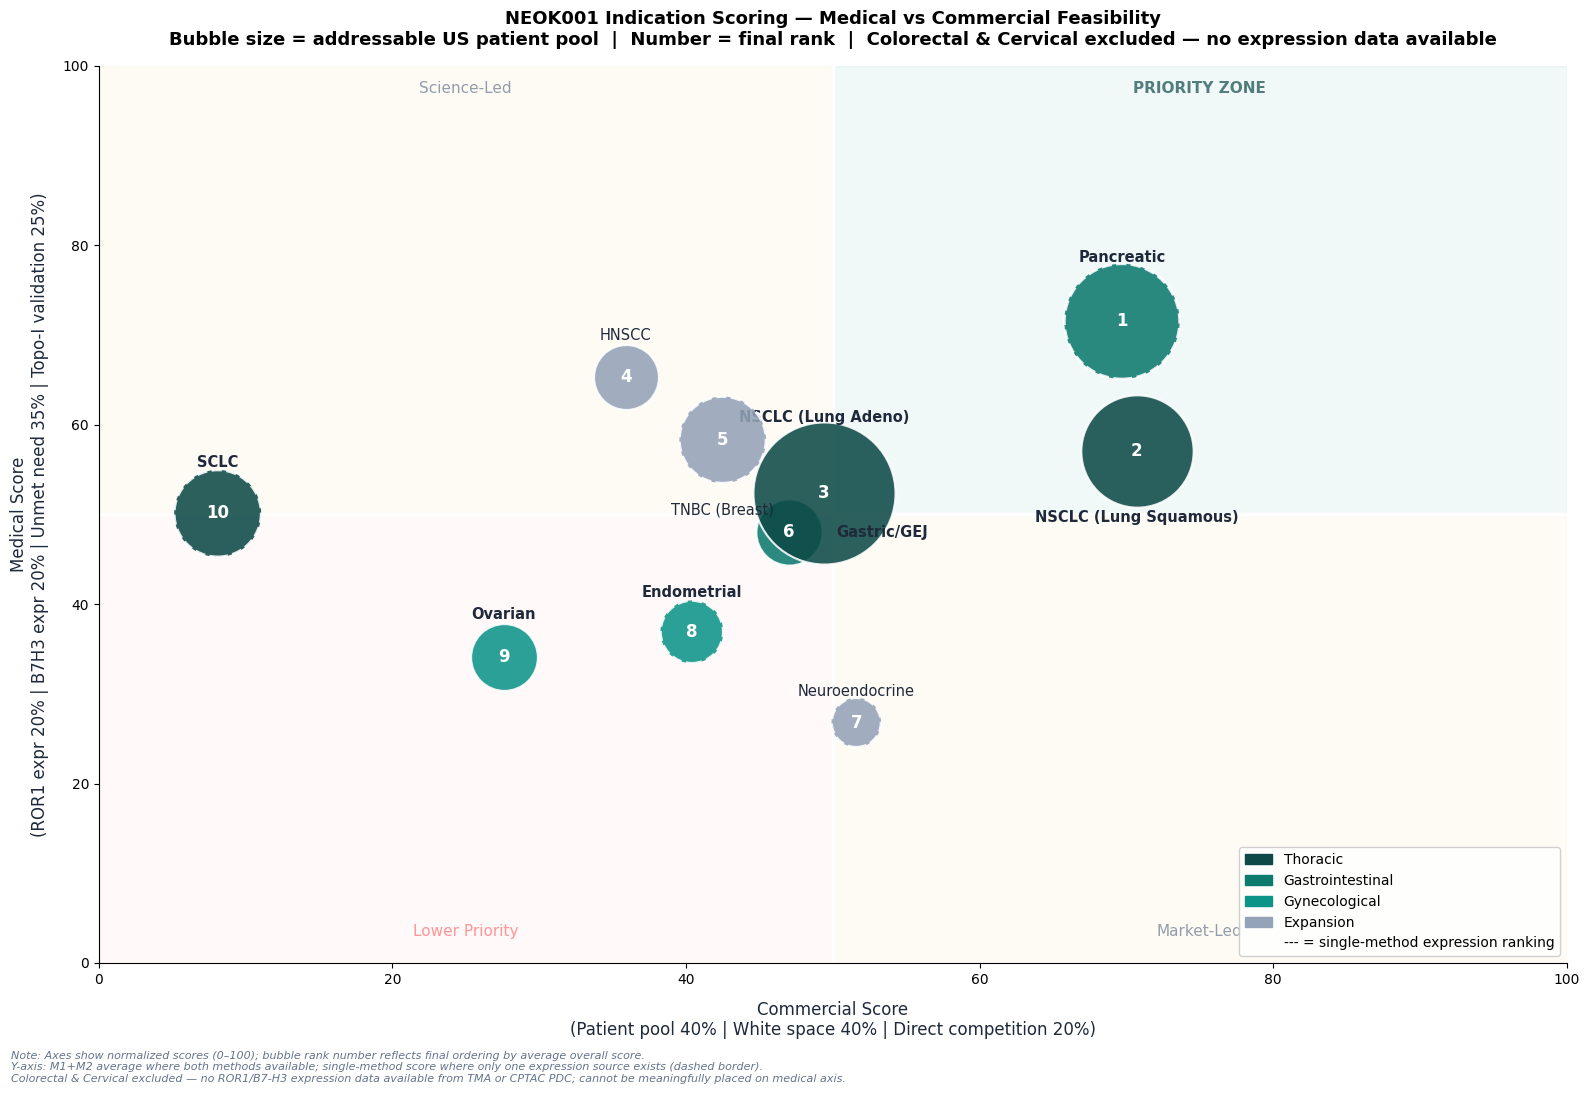

Saved to data/images/01_indication_quadrant_final.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

fig, ax = plt.subplots(figsize=(16, 11))

# ── QUADRANT BACKGROUND ──────────────────────────────────────
ax.axhspan(50, 100, xmin=0.5, xmax=1.0, alpha=0.06,
           color=NEOK_TEAL, zorder=0)
ax.axhspan(0,  50,  xmin=0.5, xmax=1.0, alpha=0.04,
           color='#F59E0B', zorder=0)
ax.axhspan(50, 100, xmin=0.0, xmax=0.5, alpha=0.04,
           color='#F59E0B', zorder=0)
ax.axhspan(0,  50,  xmin=0.0, xmax=0.5, alpha=0.04,
           color='#FF6B6B', zorder=0)

ax.axhline(50, color='white', linewidth=2.5, zorder=2)
ax.axvline(50, color='white', linewidth=2.5, zorder=2)

ax.text(75, 97, 'PRIORITY ZONE', ha='center', fontsize=11,
        color=NEOK_DARK, fontweight='bold', alpha=0.7)
ax.text(25, 97, 'Science-Led',   ha='center', fontsize=11,
        color='#64748B', alpha=0.7)
ax.text(75,  3, 'Market-Led',    ha='center', fontsize=11,
        color='#64748B', alpha=0.7)
ax.text(25,  3, 'Lower Priority', ha='center', fontsize=11,
        color='#FF6B6B', alpha=0.7)

# ── CATEGORY COLORS ──────────────────────────────────────────
cat_colors = {
    'Thoracic':         NEOK_DARK,
    'Gastrointestinal': NEOK_MID,
    'Gynecological':    NEOK_TEAL,
    'Expansion':        '#94A3B8',
}

categories = {
    'NSCLC (Lung Adeno)':    'Thoracic',
    'NSCLC (Lung Squamous)': 'Thoracic',
    'SCLC':                  'Thoracic',
    'Gastric/GEJ':           'Gastrointestinal',
    'Colorectal':            'Gastrointestinal',
    'Pancreatic':            'Gastrointestinal',
    'Ovarian':               'Gynecological',
    'Cervical':              'Gynecological',
    'Endometrial':           'Gynecological',
    'HNSCC':                 'Expansion',
    'TNBC (Breast)':         'Expansion',
    'Neuroendocrine':        'Expansion',
}

# single-source indications — dashed border
M1_ONLY       = ['TNBC (Breast)', 'SCLC', 'Neuroendocrine']
M2_ONLY       = ['Pancreatic', 'Endometrial']
SINGLE_SOURCE = M1_ONLY + M2_ONLY

# ── LABEL OFFSETS ────────────────────────────────────────────
label_offsets = {
    'Pancreatic':            (  0,    8,    'center', 'top'),
    'NSCLC (Lung Squamous)': (  0,   -6.6, 'center', 'top'),
    'NSCLC (Lung Adeno)':    (  0,    9.25,'center', 'top'),
    'Gastric/GEJ':           (  3.25, 0,   'left',   'center'),
    'SCLC':                  (  0,    6.5, 'center', 'top'),
    'HNSCC':                 (  0,    5.5, 'center', 'top'),
    'Ovarian':               (  0,    5.5, 'center', 'top'),
    'TNBC (Breast)':         (  0,   -7,   'center', 'top'),
    'Neuroendocrine':        (  0,    4.25,'center', 'top'),
    'Endometrial':           (  0,    5.2, 'center', 'top'),
}

# ── PLOT RANKED INDICATIONS ONLY ─────────────────────────────
for _, row in ranked.iterrows():
    ind  = row['Indication']
    x    = row['commercial_score']

    # avg_med — use whichever methods are applicable
    m1_ok = row['m1_applicable'] and pd.notna(row['medical_score_m1'])
    m2_ok = row['m2_applicable'] and pd.notna(row['medical_score_m2'])
    if m1_ok and m2_ok:
        avg_med = (row['medical_score_m1'] + row['medical_score_m2']) / 2
    elif m1_ok:
        avg_med = row['medical_score_m1']
    else:
        avg_med = row['medical_score_m2']

    color     = cat_colors[categories[ind]]
    size      = row['addressable_patients_yr'] / 5
    is_single = ind in SINGLE_SOURCE
    is_tnbc   = ind == 'TNBC (Breast)'

    zorder_bubble = 65 if is_tnbc else 50 - int(row['final_rank'])
    zorder_text   = 70 if is_tnbc else 60

    ax.scatter(x, avg_med,
               s=size, color=color, alpha=0.88,
               edgecolors='white',
               linewidth=2.0 if is_single else 1.5,
               linestyle='--' if is_single else '-',
               zorder=zorder_bubble)

    ax.text(x, avg_med,
            str(int(row['final_rank'])),
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color='white', zorder=zorder_text)

    dx, dy, ha, va = label_offsets.get(ind, (0, 6, 'center', 'bottom'))

    ax.text(x + dx, avg_med + dy, ind,
            ha=ha, va=va, fontsize=10.5,
            color='#1E293B', zorder=zorder_text,
            fontweight='bold' if row['neok_priority'] else 'normal')

# ── AXES AND LABELS ───────────────────────────────────────────
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel(
    'Commercial Score\n'
    '(Patient pool 40% | White space 40% | '
    'Direct competition 20%)',
    fontsize=12, color='#1E293B', labelpad=10)
ax.set_ylabel(
    'Medical Score\n'
    '(ROR1 expr 20% | B7H3 expr 20% | '
    'Unmet need 35% | Topo-I validation 25%)',
    fontsize=12, color='#1E293B', labelpad=10)
ax.set_title(
    'NEOK001 Indication Scoring — Medical vs Commercial Feasibility\n'
    'Bubble size = addressable US patient pool  |  '
    'Number = final rank  |  '
    'Colorectal & Cervical excluded — no expression data available',
    fontsize=13, fontweight='bold', pad=15)

# ── LEGEND ────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=NEOK_DARK,  label='Thoracic'),
    mpatches.Patch(color=NEOK_MID,   label='Gastrointestinal'),
    mpatches.Patch(color=NEOK_TEAL,  label='Gynecological'),
    mpatches.Patch(color='#94A3B8',  label='Expansion'),
    mpatches.Patch(facecolor='none', edgecolor='none',
                   label='--- = single-method expression ranking'),
]
ax.legend(handles=legend_handles, fontsize=10,
          loc='lower right', framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

# ── CAVEAT NOTE ──────────────────────────────────────────────
caveat = (
    "Note: Axes show normalized scores (0–100); bubble rank number "
    "reflects final ordering by average overall score.\n"
    "Y-axis: M1+M2 average where both methods available; "
    "single-method score where only one expression source exists (dashed border).\n"
    "Colorectal & Cervical excluded — no ROR1/B7-H3 expression data available "
    "from TMA or CPTAC PDC; cannot be meaningfully placed on medical axis."
)
fig.text(0.01, 0.01, caveat,
         fontsize=8, color='#64748B',
         ha='left', va='bottom',
         style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('../data/images/03_indication_quadrant_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/images/03_indication_quadrant_final.png")

### Strategic Recommendation

| Priority | Indication | Rationale |
|----------|-----------|-----------|
| **Primary** | Pancreatic (PDAC) | #1 by CPTAC, highest unmet need, least competitive, Topo-I in SOC |
| **Secondary** | NSCLC (Lung Squamous) | #2 HIGH confidence, highest ROR1 protein, least competitive NSCLC |
| **Data gap** | Colorectal, Cervical | Cannot evaluate without expression data |
